In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.regression.linear_model import OLS
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

In [3]:
# Parámetros
symbols = ["XOM", "CVX"]
# Descargarmos los datos, en este caso las acciones de ExxonMobil y Chevron, dos compañías del sector de energía
data = yf.download(symbols, start="2015-01-01", end="2024-12-31", progress=False)["Close"]
data.columns = ["XOM", "CVX"]
data = data.dropna()
#print(data)
#Creamos un dataframe para los retornos de ambas acciones
retornos = np.log(data).diff() * 100
retornos = retornos.dropna()
retornos

YF.download() has changed argument auto_adjust default to True


,XOM,CVX
Date,,
2015-01-05,-4.079256,-2.774308
2015-01-06,-0.046253,-0.533027
2015-01-07,-0.083370,1.008155
2015-01-08,2.262517,1.650779
2015-01-09,-2.012671,-0.141056
...,...,...
2024-12-23,0.083964,0.405340
2024-12-24,0.606672,0.094026
2024-12-26,0.097292,0.084549


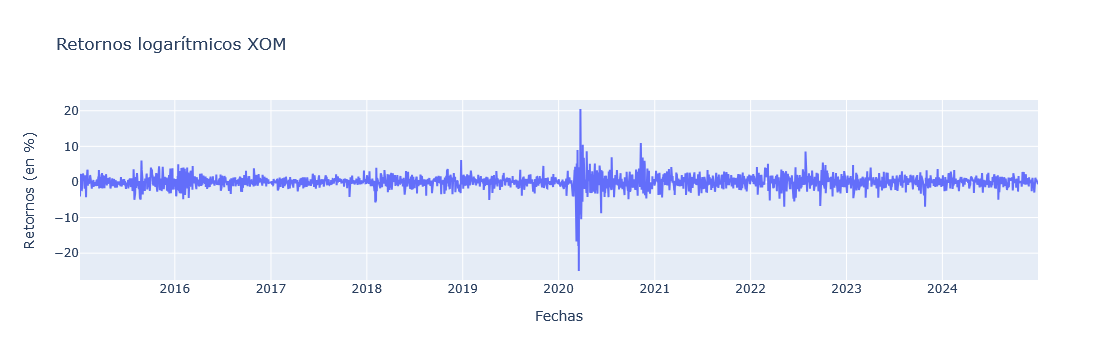

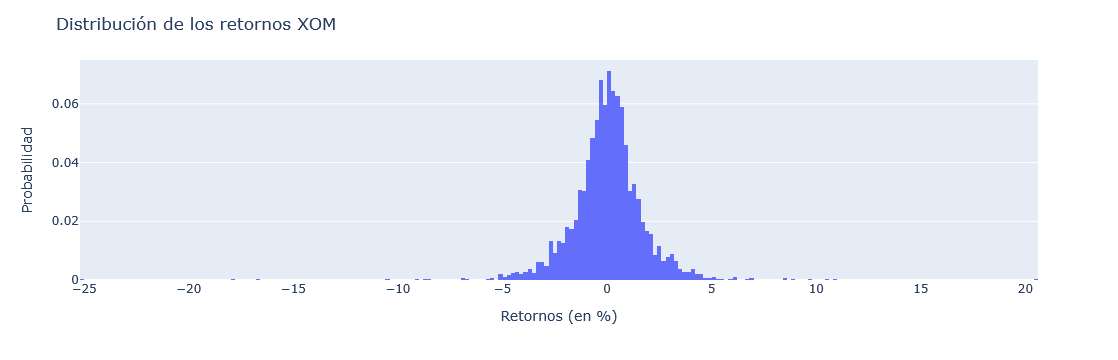

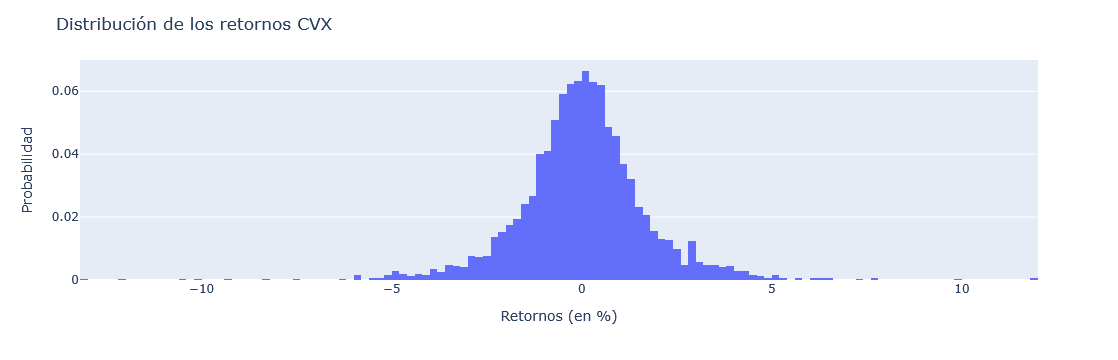

In [4]:
# Visualización de los retornos

#XOM
fig1_xom = go.Figure()
fig1_xom.add_trace(go.Scatter(x=retornos.index, y=retornos["XOM"], mode="lines", name="Retornos de XOM"))
fig1_xom.update_layout(title="Retornos logarítmicos XOM", xaxis_title="Fechas", yaxis_title="Retornos (en %)")
fig1_xom.show()

fig2_xom = px.histogram(retornos["XOM"], x="XOM", histnorm='probability')
fig2_xom.update_layout(title="Distribución de los retornos XOM", xaxis_title="Retornos (en %)", yaxis_title="Probabilidad")
fig2_xom.show()

#CVX
fig1_cvx = go.Figure()
fig1_cvx.add_trace(go.Scatter(x=retornos.index, y=retornos["CVX"], mode="lines", name="Retornos de CVX"))
fig1_cvx.update_layout(title="Retornos logarítmicos CVX", xaxis_title="Fechas", yaxis_title="Retornos (en %)")
fig1_cvx.show()

fig2_cvx = px.histogram(retornos["CVX"], x="CVX", histnorm='probability')
fig2_cvx.update_layout(title="Distribución de los retornos CVX", xaxis_title="Retornos (en %)", yaxis_title="Probabilidad")
fig2_cvx.show()


In [5]:
# Estadísticos descriptivos
estadisticos = pd.DataFrame({
    "Mean": retornos.mean(),
    "Std Dev": retornos.std(),
    "Skewness": retornos.apply(skew),
    "Kurtosis": retornos.apply(kurtosis),
    "Min": retornos.min(),
    "Max": retornos.max(),
    "Median": retornos.median()
})

print("=== Estadísticos Descriptivos ===")
print(estadisticos.round(4))

# Correlación
correlacion = retornos.corr()
print("\n=== Matriz de Correlación ===")
print(correlacion.round(4))

=== Estadísticos Descriptivos ===
       Mean  Std Dev  Skewness  Kurtosis      Min      Max  Median
XOM  0.0265   1.8748   -0.9409   26.3041 -25.0062  20.4904  0.0553
CVX  0.0225   1.7508   -0.1407    6.5388 -13.0391  11.9442  0.0167

=== Matriz de Correlación ===
        XOM     CVX
XOM  1.0000  0.8319
CVX  0.8319  1.0000


Vemos como los retornos tienen una media cercana a 0, de igual forma, estamos en la presencia de una distribución con colas gordas (sobre todo en XOM con una curtosis de 25). Ambos activos están altamente correlacionados, por lo que realizar una estrategia de pairs tradin parece interesante.

In [7]:
# En primer lugar generamos una regresión OLS simple con constante
Y = data["CVX"]
X = add_constant(data["XOM"])
model = OLS(Y, X).fit()
beta_simple = model.params["XOM"]
intercept = model.params["const"]
print("Hedge Ratio:", beta_simple, "Intercepto: ", intercept)

Hedge Ratio: 0.6489178665660651 Intercepto:  2.1539269186492187


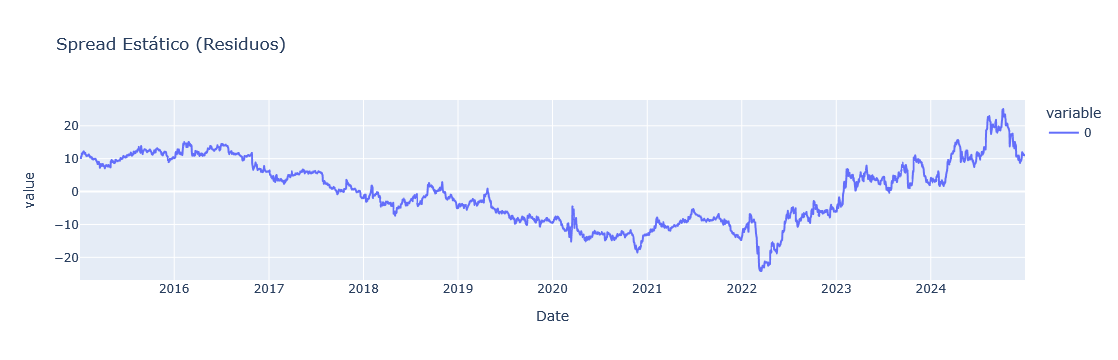

ADF stat: -1.6639370107278273 | p-value: 0.44978238842727863 
 Critical Values: {'1%': -3.4329538144697187, '5%': -2.8626903542179405, '10%': -2.567382377622466}


In [8]:
# Spread
residuals = Y - beta_simple * data["XOM"] - intercept
fig = px.line(residuals, title="Spread Estático (Residuos)")
fig.show()

#Test ADF
adf = adfuller(residuals, autolag="AIC")
print("ADF stat:", adf[0], "| p-value:", adf[1], "\n", 'Critical Values:', adf[4])

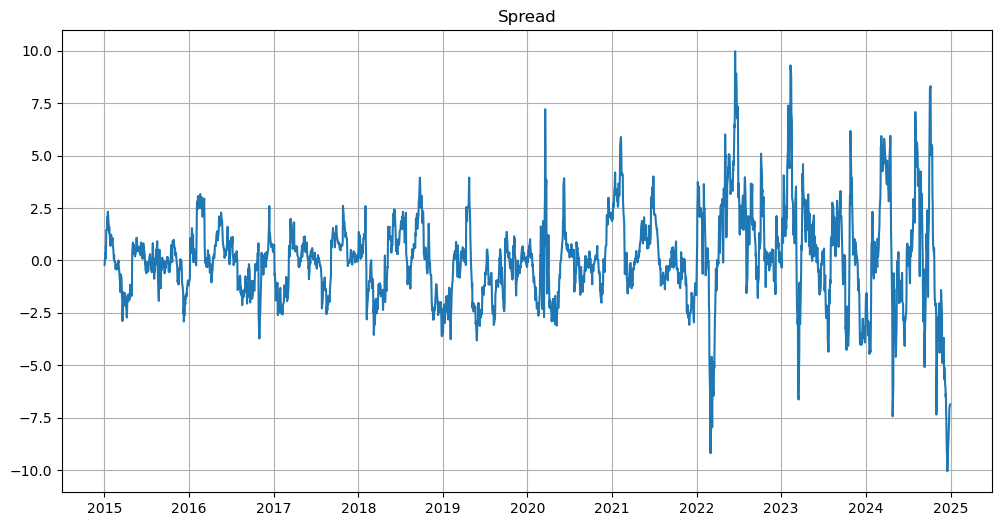

ADF stat: -7.92043146634934 | p-value: 3.736957887896252e-12 
 Critical Values: {'1%': -3.4329684108437117, '5%': -2.8626968000025603, '10%': -2.56738580944}


In [9]:
# Rolling OLS
# Partiremos con un valor de lookback y umbral de compra/venta arbitrario
lookback=60
k=2

#modelo
const = sm.add_constant(data["XOM"])
rolling_model = RollingOLS(data["CVX"], const, window=lookback).fit()

alpha = rolling_model.params["const"].bfill()
beta = rolling_model.params["XOM"].bfill()

# Spread
spread = data["CVX"] - alpha - beta * data["XOM"]

plt.figure(figsize=(12, 6))
plt.plot(spread.index, spread, label='Spread')
plt.title('Spread')
plt.grid()
plt.show()

#Test ADF para la regresión dinámica
adf = adfuller(spread, autolag="AIC")
print("ADF stat:", adf[0], "| p-value:", adf[1], "\n", 'Critical Values:', adf[4])

En este caso, el p valor nos indica que ahora la serie es estacionaria, podemos realizar una estrategia de pairs trading

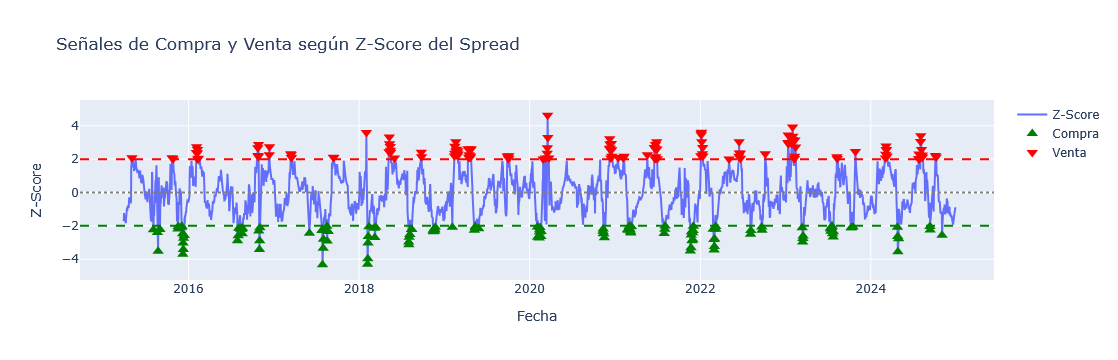

In [10]:
# Plot Z-score con umbrales

# Calculamos z-Score
zscore = (spread - spread.rolling(lookback).mean()) / spread.rolling(lookback).std()

# Generamos señales
signals = pd.Series(index=zscore.index, dtype='float')
signals[zscore > k] = -1  # Vender (Short CVX, Long XOM)
signals[zscore < -k] = 1  # Comprar (Long CVX, Short XOM)
signals[(zscore <= k) & (zscore >= -k)] = 0  # Neutral

fig = go.Figure()

fig.add_trace(go.Scatter(x=zscore.index, y=zscore, mode='lines', name='Z-Score'))

fig.add_hline(y=k, line=dict(color='red', dash='dash'))
fig.add_hline(y=-k, line=dict(color='green', dash='dash'))
fig.add_hline(y=0, line=dict(color='gray', dash='dot'))
fig.add_trace(go.Scatter(x=signals[signals == 1].index,
                         y=zscore[signals == 1],
                         mode='markers',
                         name='Compra',
                         marker=dict(color='green', symbol='triangle-up', size=10)))

fig.add_trace(go.Scatter(x=signals[signals == -1].index,
                         y=zscore[signals == -1],
                         mode='markers',
                         name='Venta',
                         marker=dict(color='red', symbol='triangle-down', size=10)))

fig.update_layout(title='Señales de Compra y Venta según Z-Score del Spread',
                  yaxis_title='Z-Score',
                  xaxis_title='Fecha')
fig.show()

In [11]:
#Creamos la funcion backtest
def backtest_general(signals, modelo, zscore, k, data, X, Y):
    nocional = 1_000_000 #El valor del nocional es completamente customizable
    df_backtest = pd.DataFrame(index=signals.index)
    df_backtest['Señal'] = signals

    # Alinear beta y precios
    beta = modelo.params[X].reindex(df_backtest.index)
    precios_X = data[X].reindex(df_backtest.index)
    precios_Y = data[Y].reindex(df_backtest.index)
    z = zscore.reindex(df_backtest.index)

    # Calcular beta según la señal
    df_backtest['Beta'] = np.where(
        signals == 1, -beta, #Largo spread (Largo Y, corto X)
        np.where(signals == -1, beta, 0) #Corto spread (Corto Y, largo X)
    )

    # Calcular posiciones (valor monetario invertido en cada activo)
    df_backtest[f'Pos_{Y}'] = df_backtest['Señal']
    df_backtest[f'Pos_{X}'] = -df_backtest['Señal'] * df_backtest['Beta']

    # Calcular retornos simples diarios
    returns = data.pct_change().reindex(df_backtest.index)

    # Calcular retornos de la estrategia aplicando posiciones del día anterior
    strategy_returns = (
        df_backtest[f'Pos_{Y}'].shift(1) * returns[Y] +
        df_backtest[f'Pos_{X}'].shift(1) * returns[X]
    )

    # Agregamos métricas
    df_backtest['retornos'] = strategy_returns
    df_backtest['valor_cartera'] = nocional * (1 + df_backtest['retornos']).cumprod()
    df_backtest['retornos acumulados'] = (df_backtest['valor_cartera'] / nocional - 1)*100

    return df_backtest

Ahora que ya tenemos una función para hacer el backtesting, realizaremos una regresión dinámica para diferentes valores de lookback y umbrales de compra/venta k de forma en que se encuentre un óptimo

In [12]:
#Iteramos los valores de lookback y k para encontrar un óptimo
lookbacks = np.arange(40, 120, 10) 
k_values = np.arange(0.5, 2.5, 0.1)

metricas = []
resultados = {}
for i in lookbacks:
    constant = sm.add_constant(data["XOM"])
    model = RollingOLS(data['CVX'], constant, window=i).fit()
    alpha = model.params["const"].bfill()
    beta = model.params["XOM"].bfill()

    # Spread dinámico y z-score con lookback actual
    spread = data["CVX"] - alpha - beta * data["XOM"]
    zscore = (spread - spread.rolling(i).mean()) / spread.rolling(i).std()

    pnl = pd.DataFrame() #Creamos un dataframe para el profit and loss

    for k in k_values:
        # Generar señales
        señal = pd.Series(0, index=zscore.index)
        señal[zscore > k] = -1 #Corto Spread
        señal[zscore < -k] = 1 #Largo Spread 

        # Ejecutar backtest
        df_resultado = backtest_general(señal, model, zscore, k, data, 'XOM', 'CVX')

        # Guardar el P&L acumulado para el gráfico
        pnl[f'k={k:.2f}'] = df_resultado['retornos acumulados']

        # Extraer retornos
        retornos = df_resultado['retornos'].dropna()
        retornos_acumulados = df_resultado['retornos acumulados'].dropna()

        # Valor final de cartera
        cartera = df_resultado['valor_cartera'].iloc[-1]

        # Métricas
        sharpe = retornos.mean() * np.sqrt(252) / retornos.std() if retornos.std() > 0 else np.nan
        drawdown = retornos_acumulados / (1 + retornos_acumulados).cummax() - 1
        max_drawdown = drawdown.min()
        cvar_95 = retornos.quantile(0.05)

        metricas.append({
            'lookback': i,
            'k': k,
            'Sharpe Ratio': sharpe,
            'Max Drawdown': max_drawdown,
            'CVaR (95%)': cvar_95,
            'Retorno Acumulado': retornos_acumulados.iloc[-1] if not retornos_acumulados.empty else np.nan,
            'Valor Cartera': int(cartera)
        })

    # Guardar los P&L por k para cada lookback
    resultados[i] = pnl

# Crear DataFrame con todas las métricas
df_metricas = pd.DataFrame(metricas)

In [13]:
#Creamos una tabla para poder visualizar de mejor manera los resultados
import dtale
dtale.show(df_metricas)

Tras analizar la tabla, vemos que para un lookback de 80 y un umbral de compra k=2.4 se obtiene el ratio de Sharpe más elevado: 0.8. Este valor indica que hay un exceso de riesgo para la rentabilidad obtenida, sin embargo es un valor aceptable. Este valor puede deberse a la alta volatilidad que hubo con los precios de acciones de energía durante el 2020.

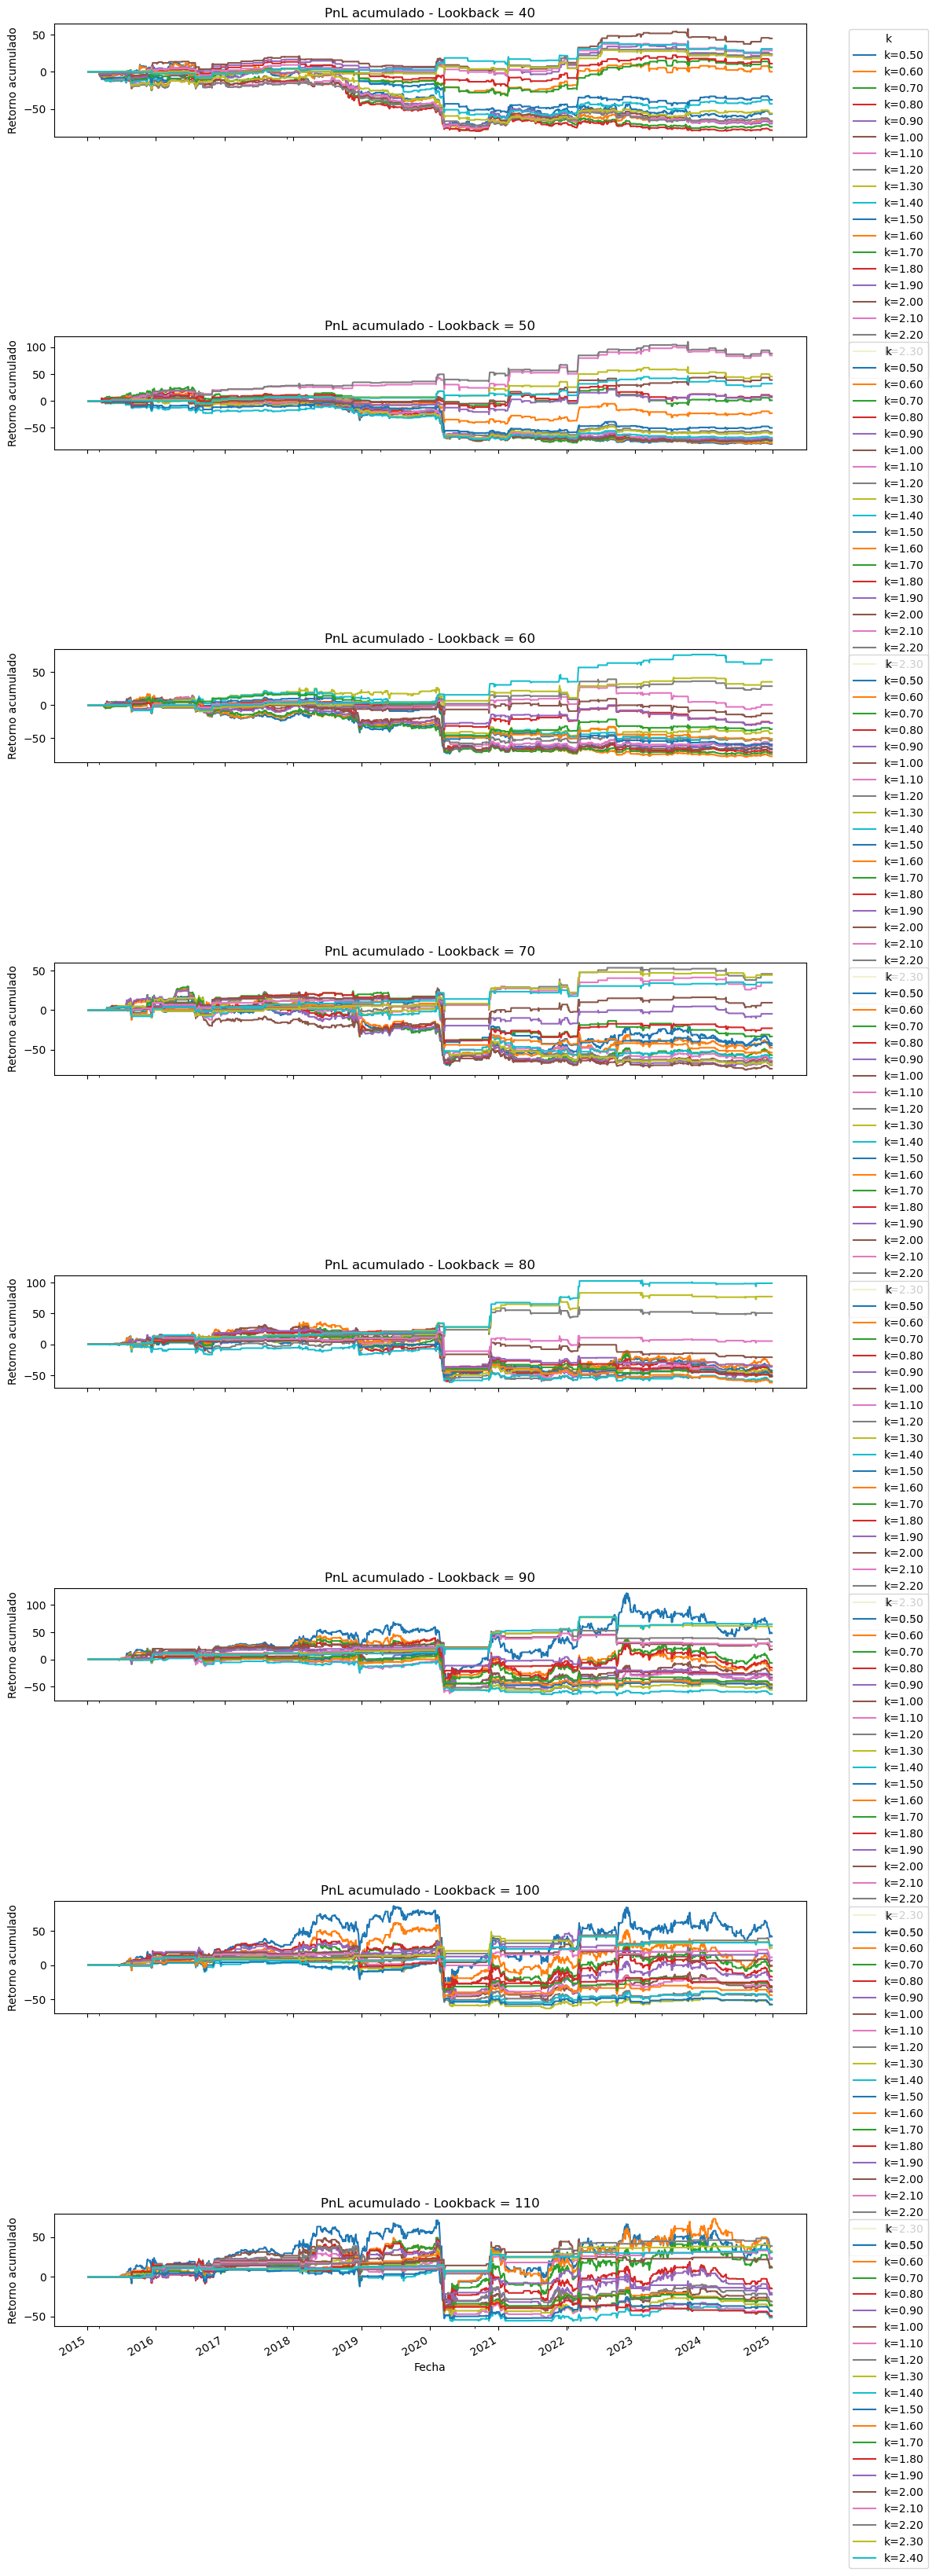

In [14]:
#Graficamos el P&L con los valores de k para cada lookback
fig, axs = plt.subplots(len(resultados), 1, figsize=(12, 4 * len(resultados)), sharex=True)

if len(resultados) == 1:
    axs = [axs]  # Asegura que sea iterable

for i, (lookback, df_pnl) in enumerate(sorted(resultados.items())):
    ax = axs[i]
    df_pnl.plot(ax=ax)
    ax.set_title(f'PnL acumulado - Lookback = {lookback}')
    ax.set_ylabel('Retorno acumulado')
    ax.legend(title='k', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Fecha')
plt.tight_layout()
plt.show()